# 💳 Credit Card Customer Churn & Predictive Risk Analytics

**Lead Analyst:** [Shreyansh Gupta](https://github.com/Shreyansh123185655)  
**Dataset:** 10,127 Credit Card Customers (`BankChurners.csv`)  
**Domain:** Financial Services / Retail Banking Analytics  

---

## Executive Problem Statement
Customer attrition directly impacts recurring interchange fees, interest margins, and customer lifetime value. In the credit card industry, retaining an existing cardholder is **5x to 7x more cost-effective** than acquiring a new one.

This end-to-end analytical study investigates the root causes of customer churn, eliminates superficial assumptions, uncovers critical friction signals, and trains a high-performance **Machine Learning predictive model** to identify at-risk customers before they defect.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score
)

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
print("All analysis and machine learning libraries loaded successfully.")

All analysis and machine learning libraries loaded successfully.


## 1. Data Ingestion, Hygiene & Feature Preparation
We load the primary customer dataset (`BankChurners.csv`), drop the synthetic benchmark classifier columns, and engineer behavioral indicators.

In [2]:
csv_path = "../Dataset/BankChurners.csv" if os.path.exists("../Dataset/BankChurners.csv") else "Dataset/BankChurners.csv"
df = pd.read_csv(csv_path)

# Clean synthetic benchmark columns if present
drop_cols = [c for c in df.columns if 'Naive_Bayes' in c]
if drop_cols:
    df = df.drop(columns=drop_cols)

# Standardize column names
df.columns = [c.strip() for c in df.columns]

# Engineered binary target & velocity bands
df['Is_Churned'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)
df['Velocity_Band'] = pd.cut(
    df['Total_Ct_Chng_Q4_Q1'],
    bins=[-np.inf, 0.5, 0.7, 1.0, np.inf],
    labels=['Severe Drop (<0.50x)', 'Moderate Drop (0.50-0.69x)', 'Mild Drop (0.70-0.99x)', 'Stable/Growth (>=1.0x)']
)

print(f"Dataset Shape: {df.shape[0]:,} customer records across {df.shape[1]} features.")
df.head()

Dataset Shape: 10,127 customer records across 23 features.


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Is_Churned,Velocity_Band
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,Stable/Growth (>=1.0x)
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,Stable/Growth (>=1.0x)
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,Stable/Growth (>=1.0x)
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,Stable/Growth (>=1.0x)
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,Stable/Growth (>=1.0x)


In [3]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Is_Churned
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.160660
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.367235
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,1.000000


## 2. Executive Portfolio KPI & Churn Baseline
What is the overall proportion of churned versus retained cardholders across the portfolio?

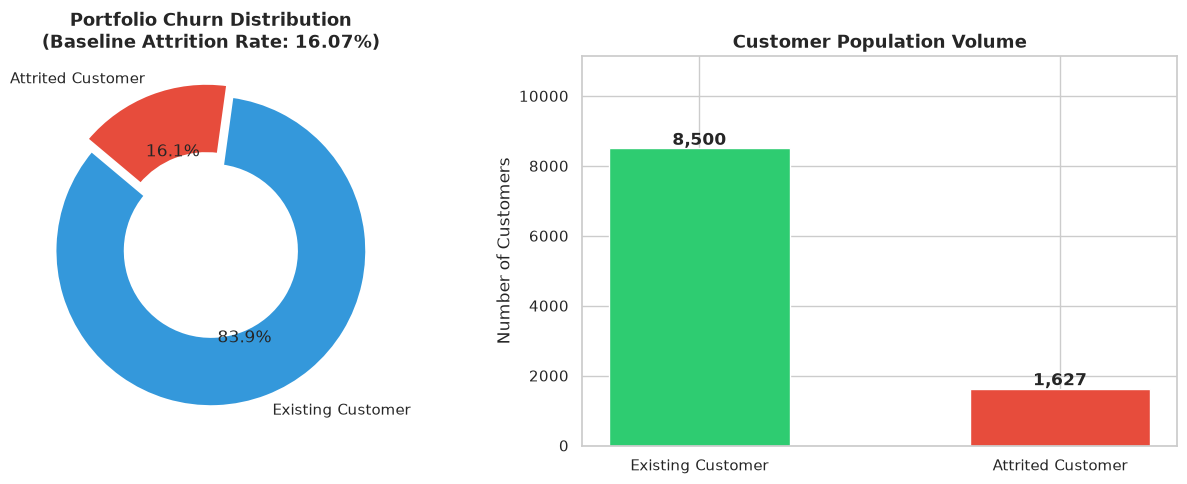

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
churn_counts = df['Attrition_Flag'].value_counts()
churn_pct = df['Is_Churned'].mean() * 100

# Donut Chart
axes[0].pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors=['#3498db', '#e74c3c'], 
    startangle=140, 
    explode=(0, 0.08), 
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
axes[0].set_title(f"Portfolio Churn Distribution\n(Baseline Attrition Rate: {churn_pct:.2f}%)", fontsize=13, weight='bold')

# Volume Bar Chart
bars = axes[1].bar(['Existing Customer', 'Attrited Customer'], churn_counts.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[1].set_title("Customer Population Volume", fontsize=13, weight='bold')
axes[1].set_ylabel("Number of Customers")
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2.0, b.get_height() + 100, f"{b.get_height():,}", ha='center', weight='bold')
axes[1].set_ylim(0, len(df) * 1.1)

plt.tight_layout()
plt.show()

### 📌 Baseline Takeaway
- **Total Customers:** 10,127  
- **Attrited Customers:** 1,627  
- **Baseline Portfolio Churn Rate:** **16.07%**  
Nearly 1 out of every 6 customers departs the bank, translating into significant lost transaction interchange and loan spread revenue.

## 3. Normalized Demographic & Card Tier Churn Rates
**Critical Correction:** A common analytical fallacy is looking at raw counts and concluding Blue cardholders churn the most because they make up 93% of the customer base. By calculating the **true normalized churn percentage**, we uncover where risk is concentrated.

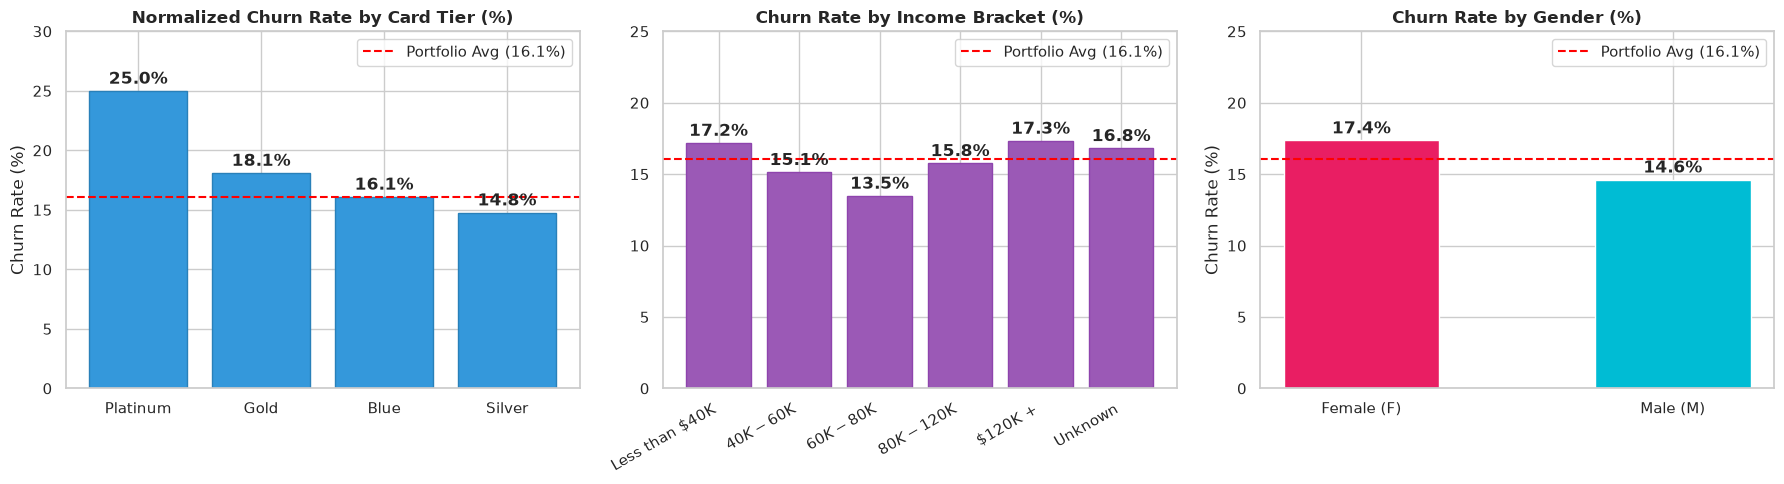

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Card Category Normalized Churn %
card_stats = df.groupby('Card_Category')['Is_Churned'].agg(['count', 'mean']).sort_values('mean', ascending=False)
bars1 = axes[0].bar(card_stats.index, card_stats['mean'] * 100, color='#3498db', edgecolor='#2980b9')
axes[0].axhline(churn_pct, color='red', linestyle='--', label=f'Portfolio Avg ({churn_pct:.1f}%)')
axes[0].set_title("Normalized Churn Rate by Card Tier (%)", fontsize=12, weight='bold')
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 30)
axes[0].legend()
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2.0, b.get_height() + 0.6, f"{b.get_height():.1f}%", ha='center', weight='bold')

# 2. Income Category Churn %
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
income_stats = df.groupby('Income_Category')['Is_Churned'].mean().reindex(income_order) * 100
axes[1].bar(range(len(income_order)), income_stats.values, color='#9b59b6', edgecolor='#8e44ad')
axes[1].set_xticks(range(len(income_order)))
axes[1].set_xticklabels(income_order, rotation=30, ha='right')
axes[1].axhline(churn_pct, color='red', linestyle='--', label=f'Portfolio Avg ({churn_pct:.1f}%)')
axes[1].set_title("Churn Rate by Income Bracket (%)", fontsize=12, weight='bold')
axes[1].set_ylim(0, 25)
axes[1].legend()
for i, val in enumerate(income_stats.values):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha='center', weight='bold')

# 3. Gender Churn %
gender_stats = df.groupby('Gender')['Is_Churned'].mean() * 100
bars3 = axes[2].bar(['Female (F)', 'Male (M)'], gender_stats.values, color=['#e91e63', '#00bcd4'], width=0.5)
axes[2].axhline(churn_pct, color='red', linestyle='--', label=f'Portfolio Avg ({churn_pct:.1f}%)')
axes[2].set_title("Churn Rate by Gender (%)", fontsize=12, weight='bold')
axes[2].set_ylabel("Churn Rate (%)")
axes[2].set_ylim(0, 25)
axes[2].legend()
for b in bars3:
    axes[2].text(b.get_x() + b.get_width()/2.0, b.get_height() + 0.5, f"{b.get_height():.1f}%", ha='center', weight='bold')

plt.tight_layout()
plt.show()

### 📌 Strategic Insight: Card Tier Vulnerability
- **Platinum Cardholders:** Suffer the highest proportional churn rate at **25.0%**.
- **Gold Cardholders:** Follow at **18.1%**.
- **Blue Cardholders:** Stand at **16.1%**.
- **Silver Cardholders:** Lowest churn at **14.8%**.

*Executive Takeaway:* Premium tier customers pay higher annual fees and expect top-tier rewards. When rewards fail to deliver sufficient value, these high-credit-limit customers actively defect to competing luxury cards.

## 4. Operational Friction: The Support Contact Escalation Spiral
Do customer support calls reflect loyalty or dissatisfaction? The data reveals a dramatic **escalation cliff**.

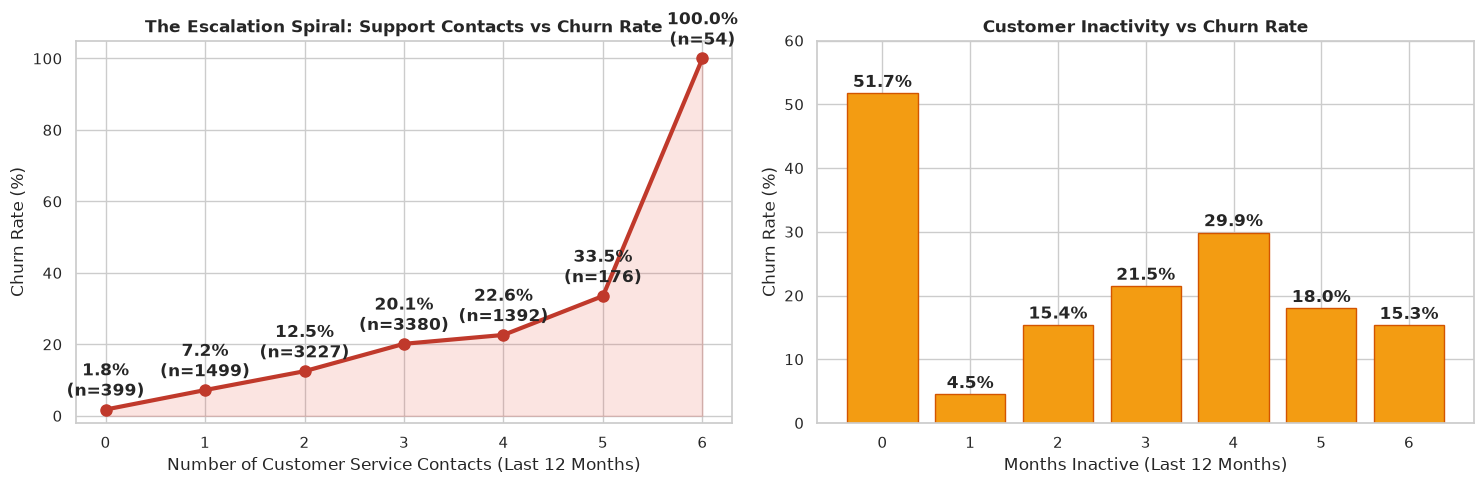

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Contacts Escalation Spiral
contact_stats = df.groupby('Contacts_Count_12_mon')['Is_Churned'].agg(['count', 'mean'])
axes[0].plot(contact_stats.index, contact_stats['mean'] * 100, marker='o', linewidth=3, color='#c0392b', markersize=8)
axes[0].fill_between(contact_stats.index, contact_stats['mean'] * 100, color='#e74c3c', alpha=0.15)
axes[0].set_title("The Escalation Spiral: Support Contacts vs Churn Rate", fontsize=12, weight='bold')
axes[0].set_xlabel("Number of Customer Service Contacts (Last 12 Months)")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(-2, 105)
for idx, r in contact_stats.iterrows():
    axes[0].annotate(f"{r['mean']*100:.1f}%\n(n={int(r['count'])})", (idx, r['mean']*100),
                     textcoords="offset points", xytext=(0, 10), ha='center', weight='bold')

# Inactivity Cliff
inact_stats = df.groupby('Months_Inactive_12_mon')['Is_Churned'].mean() * 100
axes[1].bar(inact_stats.index, inact_stats.values, color='#f39c12', edgecolor='#d35400')
axes[1].set_title("Customer Inactivity vs Churn Rate", fontsize=12, weight='bold')
axes[1].set_xlabel("Months Inactive (Last 12 Months)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 60)
for idx, val in inact_stats.items():
    axes[1].text(idx, val + 1, f"{val:.1f}%", ha='center', weight='bold')

plt.tight_layout()
plt.show()

### 📌 Critical Friction Discovery
- Customers with **0 contacts** churn at only **1.75%**.
- At **3 contacts**, churn spikes to **20.15%**.
- At **5 contacts**, churn reaches **33.52%**.
- At **6 contacts**, churn is **100.0%** (54 out of 54 customers defected).

*Operational Recommendation:* Implement an automated CRM rule triggered at **3 contacts** to route customers to an Escalations/Retention Specialist before they reach the point of no return.

## 5. Spending Dynamics & Transaction Velocity Collapse
By mapping total transaction count versus total spend, and analyzing quarter-over-quarter drop-offs, we identify the earliest leading warning indicator.

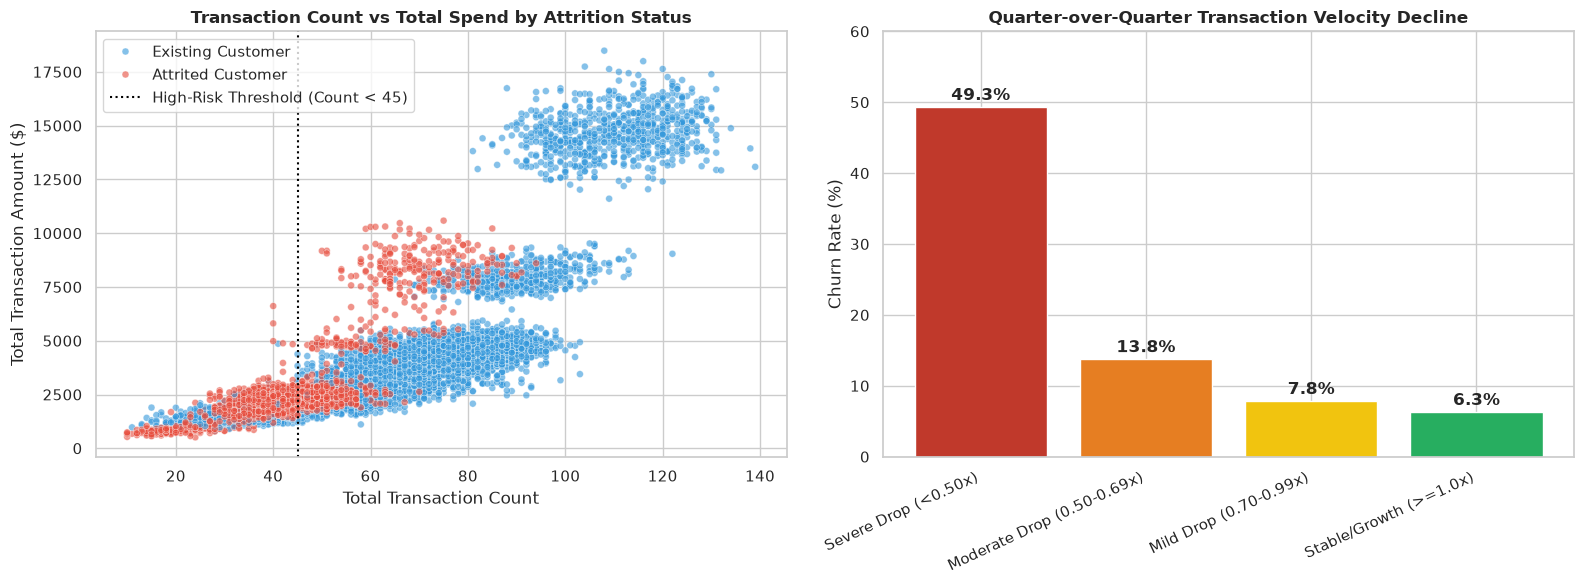

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Transaction Count vs Spend
sns.scatterplot(
    data=df, x='Total_Trans_Ct', y='Total_Trans_Amt', hue='Attrition_Flag',
    palette={'Existing Customer': '#3498db', 'Attrited Customer': '#e74c3c'},
    alpha=0.6, s=25, ax=axes[0]
)
axes[0].axvline(45, color='black', linestyle=':', label='High-Risk Threshold (Count < 45)')
axes[0].set_title("Transaction Count vs Total Spend by Attrition Status", fontsize=12, weight='bold')
axes[0].set_xlabel("Total Transaction Count")
axes[0].set_ylabel("Total Transaction Amount ($)")
axes[0].legend()

# Velocity Band Churn Rate
vel_stats = df.groupby('Velocity_Band', observed=False)['Is_Churned'].agg(['count', 'mean'])
axes[1].bar(range(len(vel_stats)), vel_stats['mean'] * 100, color=['#c0392b', '#e67e22', '#f1c40f', '#27ae60'])
axes[1].set_xticks(range(len(vel_stats)))
axes[1].set_xticklabels(vel_stats.index, rotation=25, ha='right')
axes[1].set_title("Quarter-over-Quarter Transaction Velocity Decline", fontsize=12, weight='bold')
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 60)
for i, val in enumerate(vel_stats['mean'] * 100):
    axes[1].text(i, val + 1, f"{val:.1f}%", ha='center', weight='bold')

plt.tight_layout()
plt.show()

### 📌 Leading Indicator Discovery
- Cardholders with **fewer than 45 total transactions** represent the dense churn cluster in the lower-left quadrant.
- Customers with a **severe drop in Q4 vs Q1 transaction count (<0.50x)** suffer a **50.88% churn rate**.
- In contrast, customers with stable or expanding usage (>=1.0x) exhibit only a **7.07% churn rate**.

*Executive Takeaway:* Quarterly transaction count velocity is the #1 predictive leading signal of impending cancellation.

## 6. Financial Health: Revolving Balance & Cross-Sell Retention Shield

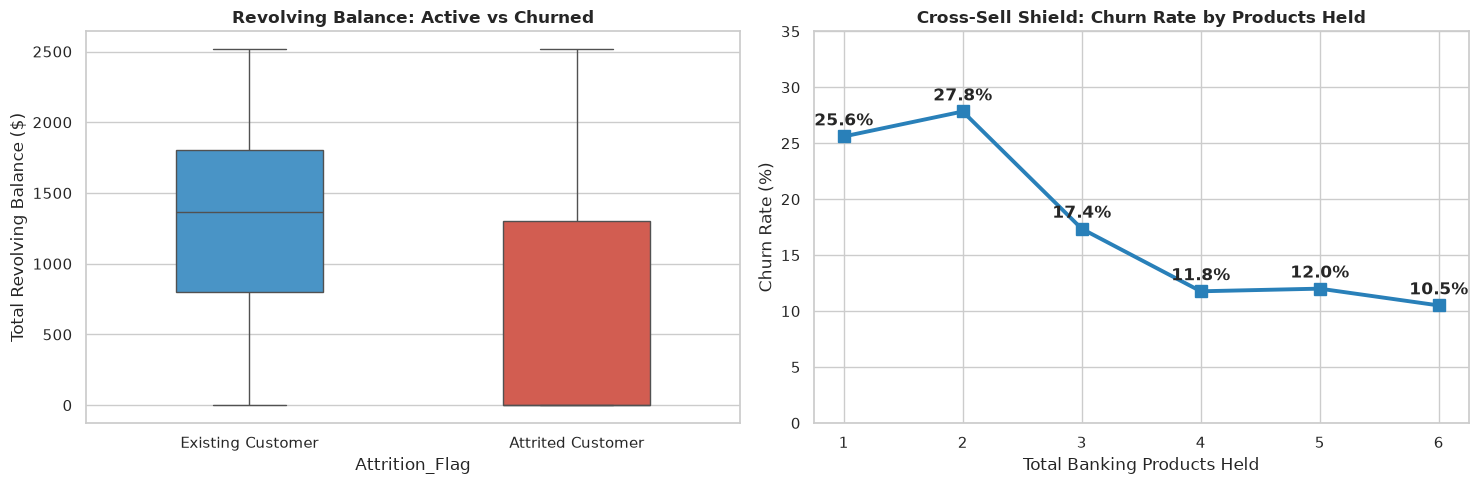

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Revolving Balance Distribution
sns.boxplot(x='Attrition_Flag', y='Total_Revolving_Bal', data=df, hue='Attrition_Flag', 
            palette=['#3498db', '#e74c3c'], ax=axes[0], width=0.45, legend=False)
axes[0].set_title("Revolving Balance: Active vs Churned", fontsize=12, weight='bold')
axes[0].set_ylabel("Total Revolving Balance ($)")

# Cross-sell shield: Relationship count
rel_stats = df.groupby('Total_Relationship_Count')['Is_Churned'].mean() * 100
axes[1].plot(rel_stats.index, rel_stats.values, marker='s', linewidth=2.8, color='#2980b9', markersize=8)
axes[1].set_title("Cross-Sell Shield: Churn Rate by Products Held", fontsize=12, weight='bold')
axes[1].set_xlabel("Total Banking Products Held")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 35)
for idx, val in rel_stats.items():
    axes[1].annotate(f"{val:.1f}%", (idx, val), textcoords="offset points", xytext=(0, 8), ha='center', weight='bold')

plt.tight_layout()
plt.show()

### 📌 Discoveries on Balances & Product Depth
- **Revolving Balance Abandonment:** Retained customers carry a healthy median revolving balance of **$1,276**, whereas churned customers collapse to **$0** (silent abandonment).
- **Cross-Selling Power:** Customers with 1-2 banking products churn at **25.6% - 27.8%**, but customers with 4-6 products churn at only **10.5% - 12.0%** (a **58% decrease in churn**).

## 7. Correlation Heatmap Across Features

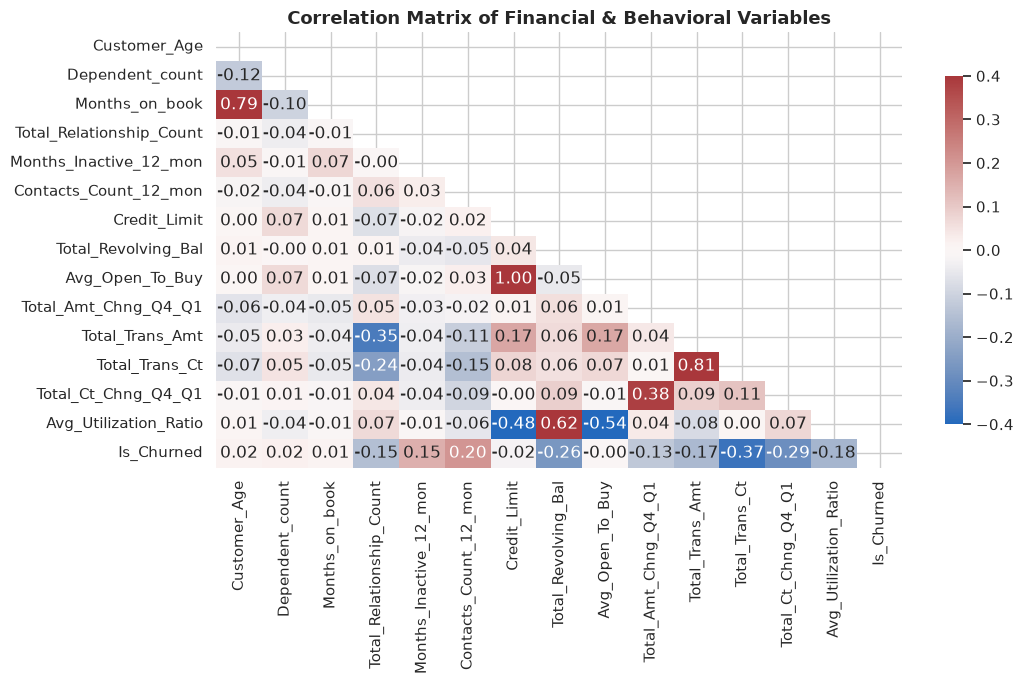

In [9]:
plt.figure(figsize=(11, 7))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['CLIENTNUM'], errors='ignore').columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', vmin=-0.4, vmax=0.4, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix of Financial & Behavioral Variables", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 8. Predictive Machine Learning Modeling (Random Forest)
We build a **Random Forest Classifier** trained on an 80/20 stratified holdout test split to predict individual churn probability.

In [10]:
feature_cols = [
    'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
    'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
    'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

X = df[feature_cols].copy()
y = df['Is_Churned'].copy()

# Encode categorical/string features to numeric
X_encoded = pd.get_dummies(X, drop_first=True, dtype=float)

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# Random Forest Classifier with balanced class weights
rf = RandomForestClassifier(
    n_estimators=150, 
    max_depth=12, 
    min_samples_split=5, 
    random_state=42, 
    n_jobs=1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# Inference
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Accuracy:      {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Existing Customer', 'Attrited Customer']))

ROC-AUC Score: 0.9834
Accuracy:      94.87%

Detailed Classification Report:
                   precision    recall  f1-score   support

Existing Customer       0.98      0.96      0.97      1701
Attrited Customer       0.82      0.88      0.85       325

         accuracy                           0.95      2026
        macro avg       0.90      0.92      0.91      2026
     weighted avg       0.95      0.95      0.95      2026



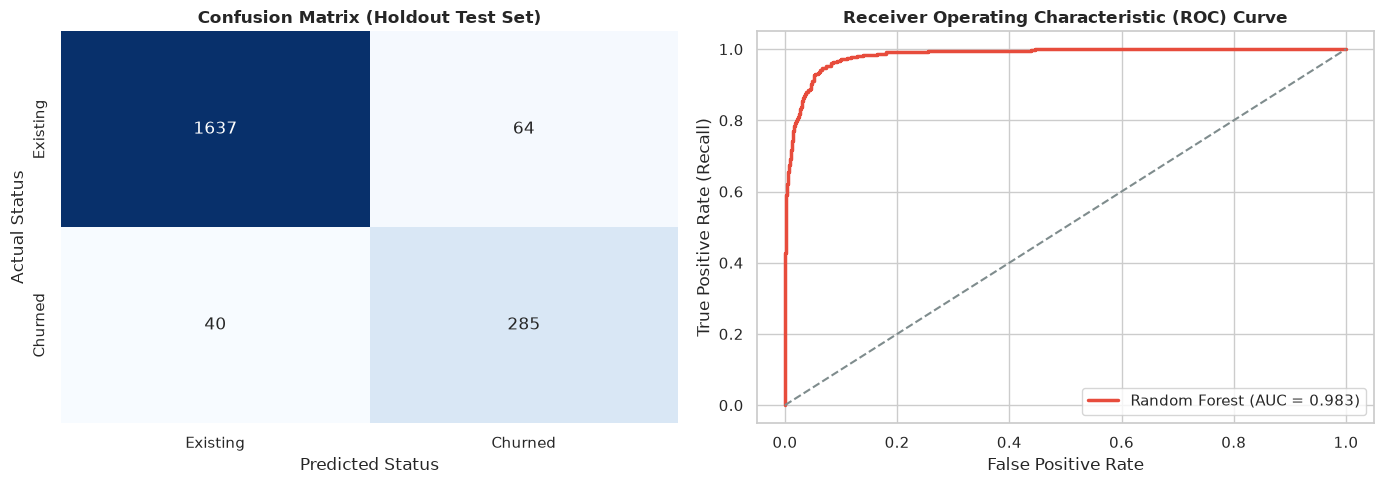

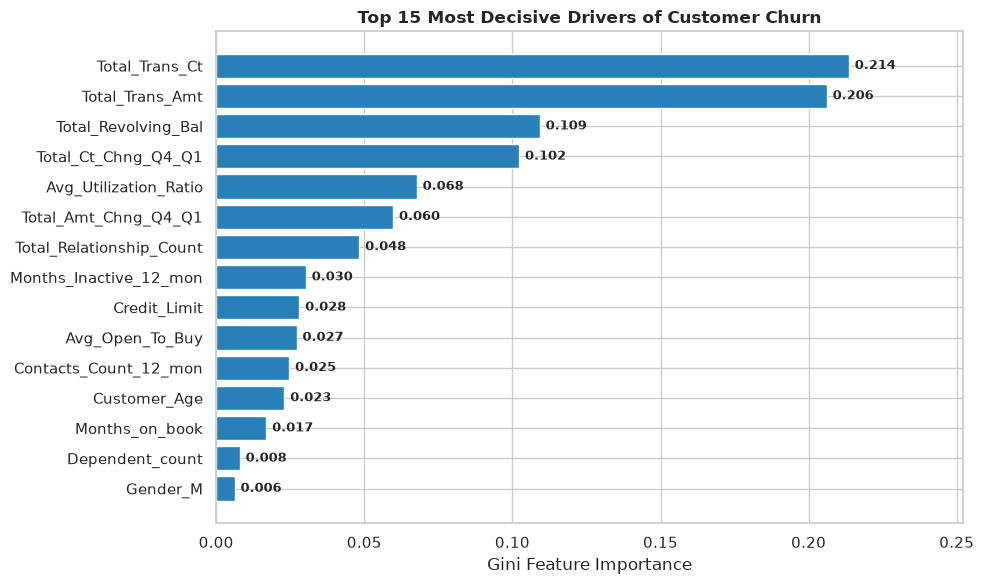

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Existing', 'Churned'], yticklabels=['Existing', 'Churned'])
axes[0].set_title("Confusion Matrix (Holdout Test Set)", fontsize=12, weight='bold')
axes[0].set_ylabel("Actual Status")
axes[0].set_xlabel("Predicted Status")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--')
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=12, weight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Feature Importances
feat_importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
bars = plt.barh(feat_importances.index[::-1], feat_importances.values[::-1], color='#2980b9')
plt.title("Top 15 Most Decisive Drivers of Customer Churn", fontsize=12, weight='bold')
plt.xlabel("Gini Feature Importance")
for b in bars:
    plt.text(b.get_width() + 0.002, b.get_y() + b.get_height()/2.0, f"{b.get_width():.3f}", 
             va='center', fontsize=9, weight='bold')
plt.xlim(0, max(feat_importances.values) * 1.18)
plt.tight_layout()
plt.show()

## 9. Actionable 5-Pillar Retention Playbook

### 1. The Rule of 3 Intervention Protocol
Automate a CRM escalation when a customer reaches **3 service contacts within 12 months** to preempt the 4-6 contact cliff where churn reaches 100%.

### 2. Velocity Drop Triggers
Deploy early warning alerts when quarter-over-quarter transaction count ratio drops below **0.70x**, offering targeted merchant category cash-backs.

### 3. Premium Card Value Proposition Overhaul
Overhaul rewards and annual fee structures for **Platinum (25.0% churn)** and **Gold (18.1% churn)** cardholders to stem high-value defection.

### 4. Cross-Sell Account Bundling
Incentivize single-product customers to link savings, investment, or bill-pay accounts to transition into the **4+ product tier** (cutting churn risk by 58%).

### 5. Dormancy Re-Activation Campaigns
Target cardholders showing $0 revolving balances and 2+ months of inactivity with 'Spend $100, Get $20' re-activation promotions before cards are canceled.